<a href="https://colab.research.google.com/github/AI-is-out-there/2026-REA-Diploma-Practical-Part/blob/dev/Telemed-conf-AI-assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import

In [6]:
!pip install torch_geometric -q

In [7]:
!pip install langchain-mistralai langchain-core langchain-community -q


In [8]:


# Импорты
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re

In [9]:
# --- ИНИЦИАЛИЗАЦИЯ ---

# Инициализация LLM (предполагается наличие API ключа)
MODEL_NAME = 'mistral-small-latest' # Или другой подходящий
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = "Kcs4YIjSQcMHrWCbIXQnE5JzXru5PTk1"
llm = ChatMistralAI(
     model=MODEL_NAME,
     temperature=0.1, # Немного повысим для разнообразия советов
     max_retries=2,
)

# Data base prototype

In [5]:


# --- БАЗЫ ДАННЫХ (Скопированы из оригинала) ---

CLINICAL_REQUIREMENTS_DB = {
    "hypertension": {
        "ru": "Диагностика и лечение артериальной гипертензии у взрослых",
        "en": "Diagnosis and Treatment of Arterial Hypertension in Adults",
        "guidelines": [
            "Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. ст.",
            "Рекомендации по фармакотерапии: ингибиторы АПФ, блокаторы кальциевых каналов, диуретики",
            "Целевые значения АД: <130/80 мм рт. ст. для пациентов с СС риском",
            "Мониторинг: регулярное измерение АД, оценка факторов риска"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
        "last_updated": "2023-01-15",
        "evidence_level": "A"
    },
    "diabetes": {
        "ru": "Диабетический сахарный диабет 2 типа",
        "en": "Type 2 Diabetes Mellitus",
        "guidelines": [
            "Диагноз СД2: Гликированный гемоглобин ≥6.5% или уровень глюкозы натощак ≥7.0 ммоль/л",
            "Терапия: метформин как препарат первого выбора",
            "Контроль целей: HbA1c <7% для большинства пациентов",
            "Осложнения: регулярный осмотр глазного дна, оценка нефропатии"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
        "last_updated": "2023-02-20",
        "evidence_level": "A"
    },
    "stroke": {
        "ru": "Острое нарушение мозгового кровообращения",
        "en": "Acute Cerebrovascular Accident",
        "guidelines": [
            "Временные рамки для тромболизиса: в течение 4.5 часов от начала симптомов",
            "Аспирин: начать в первые 24-48 часов после ишемического инсульта",
            "Реабилитация: начать в первые 24-48 часов после стабилизации",
            "Профилактика: антикоагулянты при фибрилляции предсердий"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
        "last_updated": "2023-03-10",
        "evidence_level": "A"
    },
    "heart_failure": {
        "ru": "Хроническая сердечная недостаточность",
        "en": "Chronic Heart Failure",
        "guidelines": [
            "Диагностика: ЭхоКГ, натрийуретические пептиды (BNP/NT-proBNP)",
            "Лечение: ингибиторы АПФ, бета-блокаторы, антагонисты рецепторов ангиотензина II",
            "Классификация: по функции левого желудочка (HFrEF, HFpEF)",
            "Мониторинг: симптомы, вес, ограничение жидкости и соли"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
        "last_updated": "2023-04-05",
        "evidence_level": "A"
    },
    "asthma": {
        "ru": "Бронхиальная астма у взрослых",
        "en": "Bronchial Asthma in Adults",
        "guidelines": [
            "Диагностика: спирометрия, тесты на бронходилатацию, пикфлоуметрия",
            "Терапия: ингаляционные кортикостероиды как основа базисной терапии",
            "Контроль: оценка симптомов, ограничение триггеров, самоконтроль",
            "Экзарбации: системные кортикостероиды, бронходилататоры"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
        "last_updated": "2023-05-12",
        "evidence_level": "A"
    }
}

MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "claim_4": {
            "type": "claim",
            "content": "Сердечная недостаточность требует строгой диеты с ограничением соли",
            "verdict": "supported",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_5": {
            "type": "claim",
            "content": "Астма всегда требует постоянного приема кортикостероидов",
            "verdict": "refuted",
            "confidence": 0.6,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "guideline_4": {
            "type": "guideline",
            "content": "Хроническая сердечная недостаточность",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
            "last_updated": "2023-04-05",
            "language": "ru"
        },
        "guideline_5": {
            "type": "guideline",
            "content": "Бронхиальная астма у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
            "last_updated": "2023-05-12",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        },
        "entity_7": {
            "type": "entity",
            "name": "Сердечная недостаточность",
            "category": "disease",
            "language": "ru"
        },
        "entity_8": {
            "type": "entity",
            "name": "Соль",
            "category": "dietary",
            "language": "ru"
        },
        "entity_9": {
            "type": "entity",
            "name": "Астма",
            "category": "disease",
            "language": "ru"
        },
        "entity_10": {
            "type": "entity",
            "name": "Кортикостероиды",
            "category": "medication",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_4", "target": "entity_7", "relation": "mentions", "weight": 0.9},
        {"source": "claim_4", "target": "entity_8", "relation": "mentions", "weight": 0.8},
        {"source": "claim_4", "target": "guideline_4", "relation": "supports", "weight": 0.95},
        {"source": "claim_5", "target": "entity_9", "relation": "mentions", "weight": 0.8},
        {"source": "claim_5", "target": "entity_10", "relation": "mentions", "weight": 0.7},
        {"source": "claim_5", "target": "guideline_5", "relation": "contradicts", "weight": 0.7},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_7", "target": "guideline_4", "relation": "follows", "weight": 0.9},
        {"source": "entity_9", "target": "guideline_5", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8},
        {"source": "entity_7", "target": "entity_8", "relation": "restricted_by", "weight": 0.7},
        {"source": "entity_9", "target": "entity_10", "relation": "treated_by", "weight": 0.6}
    ]
}

# Tools

# Medical Graph Visualisation

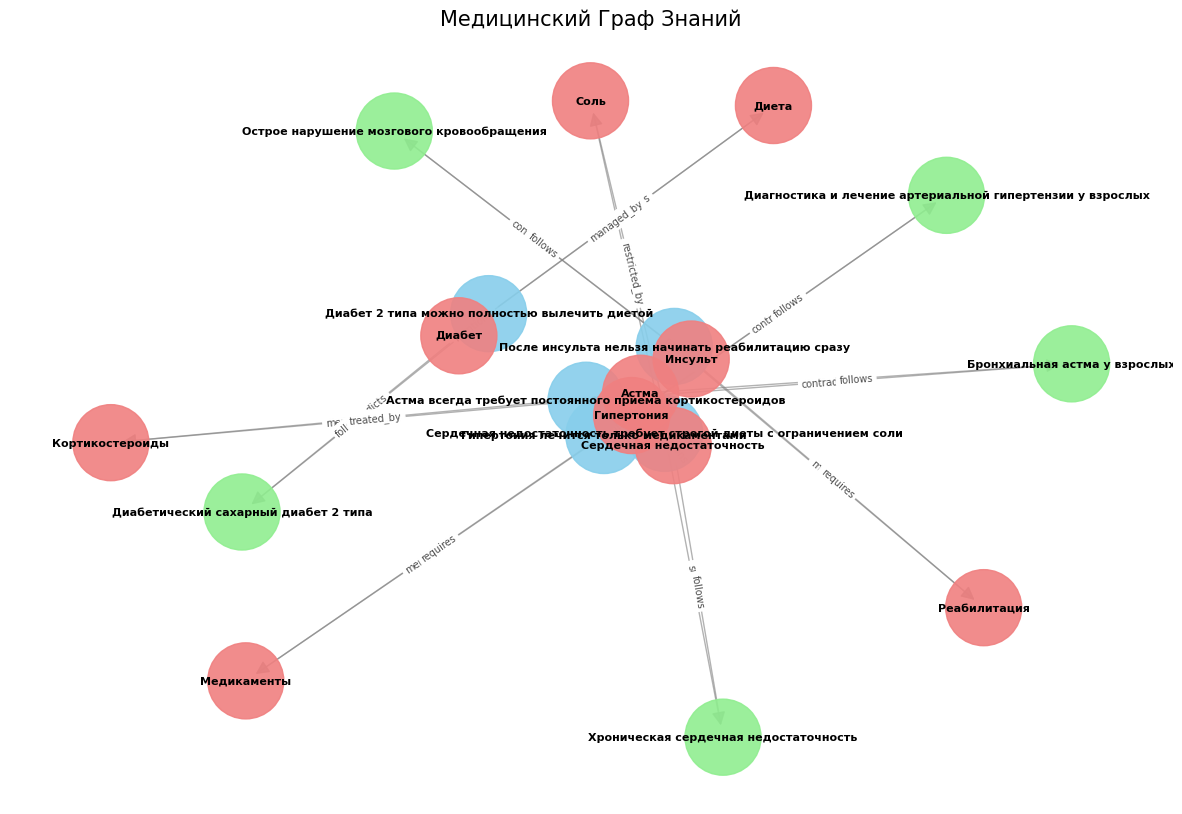

In [6]:
G = nx.DiGraph()

# Добавляем узлы
for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
    label = node_data.get("name", node_data.get("content", node_id))
    G.add_node(node_id, label=label, type=node_data["type"], category=node_data.get("category", ""), verdict=node_data.get("verdict", ""))

# Добавляем рёбра
for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"], weight=edge["weight"])

# Подготовка для визуализации
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.3, iterations=50) # Увеличиваем расстояние между узлами

# Цвета для разных типов узлов
node_colors = []
for node_id in G.nodes():
    if G.nodes[node_id]["type"] == "claim":
        node_colors.append("skyblue")
    elif G.nodes[node_id]["type"] == "guideline":
        node_colors.append("lightgreen")
    elif G.nodes[node_id]["type"] == "entity":
        node_colors.append("lightcoral")
    else:
        node_colors.append("lightgray")

# Отрисовка узлов
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Отрисовка рёбер
nx.draw_networkx_edges(G, pos, edge_color="gray", arrowsize=20, alpha=0.6)

# Метки узлов
node_labels = {node_id: G.nodes[node_id]["label"] for node_id in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight="bold")

# Метки рёбер (отношения)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, alpha=0.7)

plt.title("Медицинский Граф Знаний", size=15)
plt.axis("off")
plt.show()

In [7]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re


# --- ИНСТРУМЕНТЫ ---

@tool
def search_clinical_guidelines_ru(condition: str, language: str = "ru") -> str:
    """
    Поиск российских клинических рекомендаций по заболеванию/состоянию.
    """
    condition_lower = condition.lower()
    matching_guidelines = []
    for key, data in CLINICAL_REQUIREMENTS_DB.items():
        if condition_lower in key.lower() or condition_lower in data["ru"].lower() or condition_lower in data["en"].lower():
            matching_guidelines.append(data)

    if not matching_guidelines:
        return json.dumps({
            "summary": f"Не найдено клинических рекомендаций для '{condition}'.",
            "evidence_base": [],
            "language": language
        })

    # Возвращаем все найденные рекомендации
    results = []
    for guideline in matching_guidelines:
        if language.lower() == "ru":
            content = {
                "condition": guideline["ru"],
                "guidelines": guideline["guidelines"],
                "url": guideline["url"],
                "last_updated": guideline["last_updated"],
                "evidence_level": guideline["evidence_level"],
                "language": "ru"
            }
        else:
            content = {
                "condition": guideline["en"],
                "guidelines": guideline["guidelines"],
                "url": guideline["url"],
                "last_updated": guideline["last_updated"],
                "evidence_level": guideline["evidence_level"],
                "language": "en"
            }
        results.append(content)

    return json.dumps({
        "summary": f"Найдено {len(results)} рекомендаций для '{condition}'.",
        "evidence_base": results,
        "language": language
    }, ensure_ascii=False)


@tool
def query_clinical_knowledge_graph_ru(condition_or_issue: str, language: str = "ru") -> str:
    """
    Запрос к графу знаний для получения связанных сущностей и отношений по проблеме пациента.
    """
    # Ищем узлы, соответствующие проблеме (сущности, утверждения)
    related_nodes = {}
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        content_to_check = node_data.get("content", "") or node_data.get("name", "")
        if condition_or_issue.lower() in content_to_check.lower():
            related_nodes[node_id] = node_data

    # Если не нашли напрямую, ищем связанные узлы через рёбра
    if not related_nodes:
        for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
            source_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
            target_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]
            source_content = source_node.get("content", "") or source_node.get("name", "")
            target_content = target_node.get("content", "") or target_node.get("name", "")

            if condition_or_issue.lower() in source_content.lower() or condition_or_issue.lower() in target_content.lower():
                related_nodes[edge["source"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
                related_nodes[edge["target"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]

    if not related_nodes:
        return json.dumps({
            "issue": condition_or_issue,
            "summary": f"Не найдены узлы графа, связанные с '{condition_or_issue}'.",
            "related_entities": [],
            "relationships": [],
            "language": language
        })

    # Находим рёбра между найденными узлами
    related_edges = []
    node_ids = set(related_nodes.keys())
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] in node_ids and edge["target"] in node_ids:
            related_edges.append(edge)

    node_details = []
    for node_id, node_data in related_nodes.items():
         node_details.append({
             "id": node_id,
             "type": node_data["type"],
             "name_or_content": node_data.get("name", node_data.get("content", "")),
             "category": node_data.get("category", ""),
             "verdict": node_data.get("verdict", ""), # Только для утверждений
             "language": node_data.get("language", "ru"),
         })

    return json.dumps({
        "issue": condition_or_issue,
        "summary": f"Найдено {len(related_nodes)} связанных узлов и {len(related_edges)} связей в графе знаний.",
        "related_entities": node_details,
        "relationships": related_edges,
        "language": language
    }, ensure_ascii=False)


@tool
def generate_operator_tips_from_graph(issue: str, graph_results_str: str, language: str = "ru") -> str:
    """
    Генерирует советы оператору на основе анализа результатов запроса к графу.
    """
    try:
        graph_results = json.loads(graph_results_str)
    except json.JSONDecodeError:
        print(f"DEBUG: Failed to parse graph_results_str: {graph_results_str}")
        return json.dumps({"error": "Невозможно разобрать результаты запроса к графу.", "tips": []}, ensure_ascii=False)

    tips = []
    # Примеры правил на основе графа
    for entity_info in graph_results.get("related_entities", []):
        entity_name = entity_info.get("name_or_content", "")
        entity_type = entity_info.get("type", "")
        entity_category = entity_info.get("category", "")
        verdict = entity_info.get("verdict", "")

        if entity_type == "claim":
            if verdict == "refuted":
                tips.append(f"Важно: Утверждение, связанное с '{entity_name}', опровергнуто. Не рекомендуйте это пациенту.")
            elif verdict == "supported":
                 tips.append(f"Подтверждено: Информация о '{entity_name}' подтверждена клиническими данными.")

        if entity_category == "treatment" or entity_category == "medication":
             tips.append(f"Возможное лечение/лекарство: '{entity_name}'. Проверьте рекомендации.")

        if entity_category == "disease":
            if entity_name.lower() != issue.lower(): # Не повторять исходное заболевание
                tips.append(f"Сопутствующее заболевание/состояние: '{entity_name}'. Уточните у пациента.")


    # Проверяем связи
    for rel in graph_results.get("relationships", []):
        if rel.get("relation") == "requires" or rel.get("relation") == "treated_by":
            source_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["source"]), "")
            target_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["target"]), "")
            if source_name and target_name:
                 tips.append(f"Связь '{rel['relation']}': '{source_name}' связано с '{target_name}'. Уточните детали.")


    # Добавляем обобщённые советы на основе типов найденных узлов
    entity_types_found = set(e.get("type", "") for e in graph_results.get("related_entities", []))
    if "guideline" in entity_types_found:
        tips.append("Найдены ссылки на клинические рекомендации. Передайте пациенту или врачу.")

    return json.dumps({
        "issue": issue,
        "tips_for_operator": tips,
        "language": language
    }, ensure_ascii=False)

# Agent

In [8]:


# --- АГЕНТ ТЕЛЕМЕДИЦИНСКОГО АНАЛИЗА ---

class TelemedicineAnalysisAgent:
    """
    Агент для анализа медицинской проблемы пациента.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента
        prompt = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу: ссылки на релевантные российские клинические рекомендации.
            3. Советы оператору на основе анализа медицинского графа знаний.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию.
            - query_clinical_knowledge_graph_ru: Запрос графа знаний для получения связанных сущностей и отношений.
            - generate_operator_tips_from_graph: Генерация советов оператору на основе **прямых JSON-результатов** запроса к графу. Аргумент `graph_results_str` должен быть **полной JSON-строкой**, полученной от `query_clinical_knowledge_graph_ru`.

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме, доказательную базу и советы оператору."
        result = self.agent_executor.invoke({"input": input_text})
        return result

# Code run

In [9]:
def main():
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [search_clinical_guidelines_ru, query_clinical_knowledge_graph_ru, generate_operator_tips_from_graph]
    agent = TelemedicineAnalysisAgent(llm, tools) # Передаём mock llm

    # Пример проблемы пациента (на русском)
    patient_issue = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента


if __name__ == "__main__":
    main()

🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'артериальная гипертензия', 'language': 'ru'}`
responded: Хорошо, я начну анализ медицинской проблемы пациента.

**Шаг 1:** Краткое резюме проблемы.
Пациент сообщает о наличии высокого давления и головных болей, подозревает у себя гипертонию. Это может указывать на возможное наличие артериальной гипертензии, но требует подтверждения и дополнительной диагностики.

**Шаг 2:** Поиск клинических рекомендаций.
Я выполню поиск клинических рекомендаций по теме "гипертония" или "артериальная гипертензия" на русском языке.

{"summary": "\u041d\u0435 \u043d\u0430\u0439\u0434\u0435\u043d\u043e \u043a\u043b\u0438\u043d\u0438\u0447\u0435\u0441\u043a\u0438\u0445 \u0440\u0435\u043a\u043e\u043c\u0

# Special Section - find propper CR

In [11]:
!pip install mistralai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.


In [19]:
import os

from langchain_mistralai import ChatMistralAI

# Initialize ChatMistralAI with the correct model and parameters
client = ChatMistralAI(
    model="open-mistral-nemo",
    api_key=os.environ.get("MISTRAL_API_KEY"),
    temperature=0.7,
    max_tokens=2048,
    top_p=1
)

# Original inputs list
inputs = [
        {
            "role": "user",
            "content": "привет"
        },
        {
            "role": "assistant",
            "content": """Привет! Я специализированный медицинский помощник, который ищу и извлекаю клинические рекомендации с официального сайта Министерства здравоохранения РФ.

**Чем могу помочь?**
Укажите:
- **Симптомы** (например: *"кашель с кровью, одышка, лихорадка"*)
- **Диагноз** (например: *"внебольничная пневмония"*)
- **Код МКБ-10** (например: *J18, R04.2*)

Я найду актуальные клинические рекомендации и представлю алгоритм действий врача в структурированном виде."""
        },
        {
            "role": "user",
            "content": "высокое артериальное давление"
        },
        {
            "role": "assistant",
            "content": """```markdown
---
### [Артериальная гипертензия у взрослых](https://cr.minzdrav.gov.ru/preview-cr/154)
**Код МКБ-10:** I10-I15 **Год публикации:** 2023

**Симптомы/Заболевание:**
Стоящее повышение систолического АД ≥ 140 мм рт. ст. и/или диастолического АД ≥ 90 мм рт. ст. (в том числе при приеме гипотензивных препаратов).

---
#### **Алгоритм действий врача**

 | **Этап**               | **Действия**                                                                 |
 |------------------------|-----------------------------------------------------------------------------|
 | **1. Диагностика**     | - Измерение АД на обеих руках (2 раза с интервалом 1–2 минуты, среднее значение).
 |                        | - Суточное мониторирование АД (СМАД) или самоконтроль АД в домашних условиях.
 |                        | - ЭКГ, эхокардиография, анализ крови (глюкоза, липидный профиль, креатинин), мочи (белок, альбумин).
 |                        | - Оценка поражения органов-мишеней (глазное дно, сосуды сетчатки, функции почек).
 | **2. Стратификация риска** | - Определение группы риска (низкий, средний, высокий, очень высокий) на основе уровня АД, факторов риска, поражения органов-мишеней и ассоциированных заболеваний.
 | **3. Лечение**         | - **Немедикаментозная терапия:** ограничение соли (<5 г/сут), алкоголя, отказ от курения, нормализация массы тела, физическая активность.
 |                        | - **Медикаментозная терапия:** назначение гипотензивных препаратов (ингибиторы АПФ, блокаторы рецепторов ангиотензина II, диуретики, антагонисты кальция, бета-блокаторы) в зависимости от коморбидности.
 |                        | - Цель: снижение АД < 140/90 мм рт. ст. (для пациентов старше 65 лет — < 150/90 мм рт. ст., при хорошей переносимости — < 140/90 мм рт. ст.).
 | **4. Неотложная помощь** | - При гипертоническом кризе (АД ≥ 180/120 мм рт. ст. с симптомами поражения органов-мишеней): срочная госпитализация.
 |                        | - парентеральное введение гипотензивных препаратов (например, нитропруссид натрия, лабеталол) под контролем АД.
 |                        | - При отсутствии симптомов поражения органов-мишеней: пероральный прием быстродействующих препаратов (каптоприл, нифедипин).

---
**Примечания:**
- При резистентной артериальной гипертензии (АД не снижается despite терапии 3 и более препаратами) исключить вторичные причины (реноваскулярная гипертензия, феохромоцитома и др.).
- **Противопоказания:** Индивидуальная непереносимость препаратов, беременность (некоторые группы препаратов противопоказаны).

**Источник:** [Клинические рекомендации по артериальной гипертензии](https://cr.minzdrav.gov.ru/preview-cr/154)
```"""
        },
        {
            "role": "user",
            "content": "головные боли"
        },
        {
            "role": "assistant",
            "content": """```markdown
---
### [Головная боль напряжения](https://cr.minzdrav.gov.ru/preview-cr/320)
**Код МКБ-10:** G44.2 **Год публикации:** 2022

**Симптомы/Заболевание:**
Эпизодическая или хроническая двусторонняя головная боль давящего или сжимающего характера, средней интенсивности, не усугубляющаяся при физической нагрузке. Часто ассоциирована со стрессом, напряжением мышц головы и шеи.

---
#### **Алгоритм действий врача**

 | **Этап**               | **Действия**                                                                 |
 |------------------------|-----------------------------------------------------------------------------|
 | **1. Диагностика**     | - Сбор анамнеза: характер, локализация, интенсивность, длительность боли, триггеры (стресс, недосыпание).
 |                        | - Неврологический осмотр (исключение очаговой симптоматики).
 |                        | - Дополнительные методы (при подозрении на вторичную причину): МРТ/КТ головы, анализы крови (общий, биохимический), измерение артериального давления).
 | **2. Дифференциальная диагностика** | - Исключить мигрень, кластерную головную боль, симптоматические головные боли (при опухолях, кровоизлияниях, менингите и др.).
 | **3. Лечение**         | - **Немедикаментозное:** коррекция образа жизни (нормализация сна, уменьшение стресса, регулярная физическая активность), массаж, физиотерапия (например, иглорефлексотерапия).
 |                        | - **Медикаментозное (при эпизодической головной боли):** НПВС (ибупрофен 400 мг, парацетамол 500–1000 мг) или комбинированные анальгетики (не более 10 дней в месяц).
 |                        | - **Mедикаментозное (при хронической головной боли):** трициклические антидепрессанты (амитриптилин 10–75 мг/сут), СИОЗС (флуоксетин, сертралин), миорелаксанты (толперизон).
 | **4. Неотложная помощь** | - Не требуется, если исключены угрожающие жизни состояния.

---
**Примечания:**
- При подозрении на **вторичную головную боль** (внезапное начало, нарастающая интенсивность, неврологический дефицит, лихорадка) — срочная госпитализация для исключения патологии головного мозга.
- **Противопоказания:** Индивидуальная непереносимость препаратов, беременность (некоторые группы препаратов противопоказаны).

**Источник:** [Клинические рекомендации по головной боли напряжения](https://cr.minzdrav.gov.ru/preview-cr/320)

---

---
### [Мигрень](https://cr.minzdrav.gov.ru/preview-cr/319)
**Код МКБ-10:** G43 **Год публикации:** 2022

**Симптомы/Заболевание:**
Эпизоды интенсивной пульсирующей боли, чаще односторонней, длительностью от 4 до 72 часов. Сопровождается тошнотой, рвотой, светобоязнью, звукобоязнью. Может предшествовать aura (зрительные, сенсорные или речевые нарушения).

---
#### **Алгоритм действий врача**

 | **Этап**               | **Действия**                                                                 |
 |------------------------|-----------------------------------------------------------------------------|
 | **1. Диагностика**     | - Диагноз ставится на основании анамнеза и клинической картины (критерии ICHD-3).
 |                        | - Неврологический осмотр для исключения очаговой симптоматики.
 |                        | - Дополнительные методы (при атипичном течении): МРТ/КТ головы для исключения структурных поражений.
 | **2. Дифференциальная диагностика** | - Исключить другие виды головной боли (кластерная, головная боль напряжения), а также симптоматические причины (субарахноидальное кровоизлияние, менингит, опухоль).
 | **3. Лечение приступа** | - **Легкая/средняя интенсивность:** НПВС (ибупрофен 400–600 мг, напроксен 500–750 мг), ацетилсалициловая кислота 1000 мг или парацетамол 1000 мг).
 |                        | - **Тяжелая интенсивность:** триптаны (суматриптан 50–100 мг per os или назально, элетриптан 40 мг). При неэффективности — повторный прием через 2 часа (не более 2 доз в сутки).
 |                        | - **Сопутствующие симптомы:** противорвотные (метоклопрамид 10 мг, домперидон 10–20 мг).
 | **4. Профилактика**   | - **Немедикаментозная:** избегание триггеров (стресс, определенные продукты, недосыпание), регулярные физические нагрузки, релаксационные техники).
 |                        | - **Медикаментозная (при частых приступах ≥ 4 в месяц):** бета-блокаторы (пропранолол 40–160 мг/сут), блокаторы кальциевых каналов (верапамил), антидепрессанты (амитриптилин), антиконвульсанты (топирамат, вальпроат).
 | **5. Неотложная помощь** | - При подозрении на **осложненную мигрень** (неврологический дефицит, судороги) или **инсульт** — срочная госпитализация.

---
**Примечания:**
- **Триптаны противопоказаны** при ишемической болезни сердца, неконтролируемой артериальной гипертензии, беременности.
- При частом использовании анальгетиков (>10 дней в месяц) риск развития **абузусной головной боли** — требуется отмена препаратов под наблюдением врача.

**Источник:** [Клинические рекомендации по мигрени](https://cr.minzdrav.gov.ru/preview-cr/319)
```"""
        },
        {
            "role": "user",
            "content": "мигрень"
        },
        {
            "role": "assistant",
            "content": """```markdown
---
### [Мигрень](https://cr.minzdrav.gov.ru/preview-cr/319)
**Код МКБ-10:** G43 **Год публикации:** 2022

**Симптомы/Заболевание:**
Хроническое неврологическое заболевание, характеризующееся приступами интенсивной пульсирующей головной боли, чаще односторонней. Длительность приступа — от **4 до 72 часов**. Сопровождается **тошнотой, рвотой, светобоязнью (фотофобия), звукобоязнью (фонофобия)**. У 20–30% пациентов приступу предшествует **аура** (зрительные, сенсорные или речевые нарушения).

---
#### **Алгоритм действий врача**

| **Этап**               | **Действия**                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| **1. Диагностика**     | - **Критерии диагноза (ICHD-3):**
  - ≥5 приступов, длящихся **4–72 часа** (без лечения).
  - Головная боль имеет **≥2 из следующих характеристик**: односторонняя локализация, пульсирующий характер, средняя/высокая интенсивность, усиливается при физической нагрузке.
  - Сопровождается **≥1 из следующих симптомов**: тошнота/рвота, светобоязнь, звукобоязнь.
  - Исключены другие причины головной боли.
|                        | - **Неврологический осмотр** для исключения очаговой симптоматики (парезы, афазия, атаксия).
|                        | - **Дополнительные методы** (при атипичном течении):
  - МРТ/КТ головы (исключение опухолей, сосудистых мальформаций, инсульта).
  - ЭЭГ (при подозрении на эпилепсию).
  - Анализы крови (общий, биохимический, гормональный профиль при подозрении на эндокринные нарушения).
| **2. Дифференциальная диагностика** | - Исключить:
  - **Кластерную головную боль** (короткие приступы, строгая односторонность, вегетативные симптомы: слезотечение, ринорея).
  - **Головная боль напряжения** (двусторонняя, давящая, не пульсирующая).
  - **Вторичные причины**: субарахноидальное кровоизлияние (внезапная "громоподобная" боль), менингит (лихорадка, ригидность затылочных мышц), опухоль головного мозга (прогрессирующая боль, очаговые симптомы).
| **3. Лечение приступа** | - **Немедикаментозные меры**:
  - Уединение в темном, тихом помещении.
  - Холодный компресс на лоб/шею.
  - Умеренные физические нагрузки (ходьба на свежем воздухе).
|                        | - **Mедикаментозное лечение (в порядке предпочтения)**:
  | **Препарат**               | **Доза**                     | **Особенности**                          |
  |----------------------------|------------------------------|------------------------------------------|
  | Ибупрофен                  | 400–600 мг per os            | Прием в начале приступа                  |
  | Напроксен                  | 500–750 мг per os            | Альтернатива ибупрофену                  |
  | Ацетилсалициловая кислота | 1000 мг per os               | Противопоказана при язвенной болезни     |
  | Парацетамол                | 1000 мг per os               | Менее эффективен, но безопасен при беременности |
  | **Триптаны** (1-й выбор при тяжелых приступах) | | |
  | Суматриптан                | 50–100 мг per os или назально | Повторный прием через 2 часа (макс. 2 дозы/сутки) |
  | Элетриптан                 | 40 мг per os                 | Более селективен, меньше побочных эффектов |
  | Золмитриптан               | 2,5–5 мг per os              | Длительное действие                       |
  | **Противорвотные** (при тошноте/рвоте) | | |
  | Метоклопрамид             | 10 мг per os/внутримышечно   | Ускоряет всасывание анальгетика          |
  | Домперидон                 | 10–20 мг per os              | Меньше побочных эффектов                  |
| **4. Профилактика приступов** | - **Показания**: ≥4 приступов в месяц, низкая эффективность купирующей терапии, ухудшение качества жизни.
|                        | - **Немедикаментозная профилактика**:
  - Исключение **триггеров** (стресс, недосыпание, голод, алкоголь, кофеин, шоколад, сыры, нитраты).
  - Регулярные **аэробные нагрузки** (ходьба, плавание, велосипед).
  - Техники релаксации (йога, медитация, биологическая обратная связь).
|                        | - **Медикаментозная профилактика** (выбор препарата зависит от коморбидности):
  | **Группа препаратов**       | **Препарат**       | **Доза**               | **Показания/особенности**               |
  |-----------------------------|-------------------|------------------------|------------------------------------------|
  | Бета-блокаторы              | Пропранолол       | 40–160 мг/сут          | Противопоказаны при астме, АВ-блокаде    |
  |                             | Метопролол        | 50–200 мг/сут          | Селективный, лучше переносится           |
  | Блокаторы кальциевых каналов| Верапамил         | 80–240 мг/сут          | Эффективен при мигрени с аурой           |
  | Антидепрессанты             | Амитриптилин      | 10–75 мг/сут           | Противопоказан при глаукоме, аденоме простаты |
  |                             | Флуоксетин        | 20–40 мг/сут           | СИОЗС, меньше побочных эффектов           |
  | Антиконвульсанты            | Топирамат         | 25–100 мг/сут          | Эффективен при резистентной мигрени      |
  |                             | Вальпроат         | 300–600 мг/сут         | Противопоказан при беременности          |
  | Ингибиторы CGRP             | Эренумаб          | 70–140 мг подкожно 1 раз в месяц | Новая группа, высокая эффективность при резистентной мигрени |
| **5. Неотложная помощь** | - **Показания для госпитализации**:
  - Подозрение на **осложненную мигрень** (мигренозный инсульт, судороги).
  - Подозрение на **вторичную головную боль** (внезапная интенсивная боль, неврологический дефицит, лихорадка, ригидность затылочных мышц).
  - **Статус мигрени** (приступ длится >72 часов несмотря на лечение).

---
**Примечания:**
- **Триптаны противопоказаны** при:
  - Ишемической болезни сердца, инфаркте миокарда в анамнезе.
  - Неконтролируемой артериальной гипертензии.
  - Беременности (исключение: суматриптан в минимальных дозах по строгим показаниям).
  - Приеме ингибиторов МАО (риск серотонинового синдрома).
- **Абузусная головная боль** — при частом использовании анальгетиков (>10 дней в месяц) — требуется отмена препаратов под наблюдением врача.

**Источник:** [Клинические рекомендации по мигрени](https://cr.minzdrav.gov.ru/preview-cr/319)
```"""
        },
        {
            "role": "user",
            "content": "пнемвония"
        }
    ]

# The completion_args are now passed directly to the ChatMistralAI constructor
# tools are not used in this specific client.invoke call context.

# Move instructions into the inputs list as a system message
instructions_content = """TARGET: cr.minzdrav.gov.ru\n\nDo NOT rely on Google site: searches.\n\nASSUMPTIONS:\n\n* The site is a JavaScript application.\n* Recommendation metadata is loaded dynamically.\n* Search engines index only a fraction of available content.\n\nDISCOVERY STRATEGY:\n\n1. Open:\n   https://cr.minzdrav.gov.ru/clin-rec/\n
2. Inspect browser network traffic.\n   Capture:\n   * XHR requests\n   * Fetch requests\n   * JSON responses\n   * GraphQL requests if present\n
3. Identify:\n
   * recommendation list endpoint\n   * ICD-10 filter endpoint\n   * search endpoint\n   * recommendation detail endpoint\n
4. Enumerate all recommendations from backend APIs.\n   Store:\n   {\n   id,\n   title,\n   icd10_codes,\n   age_group,\n   developer,\n   publication_date,\n   status,\n   detail_url\n   }\n
5. Never scrape rendered HTML first.\n   Prefer:\n   API \u2192 JSON \u2192 document URL\n
6. For disease lookup:\n   Search both:\n
   * title\n   * ICD-10 code\n   * synonyms\n
Example:\npneumonia\n\u043f\u043d\u0435\u0432\u043c\u043e\u043d\u0438\u044f\n\u0432\u043d\u0435\u0431\u043e\u043b\u044c\u043d\u0438\u0447\u043d\u0430\u044f \u043f\u043d\u0435\u0432\u043c\u043e\u043d\u0438\u044f\ncommunity acquired pneumonia\nJ12\nJ13\nJ14\nJ15\nJ16\nJ17\nJ18\n
7. Build local full-text index.\n   Recommended fields:\n
   * title\n   * ICD-10\n   * recommendation text\n   * references\n   * tables\n   * algorithms\n
8. If API access fails:\n   Crawl:\n   /schema/*\n   /recomend/*\n   /recommend/*\n   /clin-rec/*\n   discovered links\n
9. Do not trust Google result counts.\n   Source of truth = backend API.\n
10. Output:\n    {\n    query,\n    matched_recommendations,\n    confidence,\n    source_urls\n    }\n"""

# Create the full messages list including the system instruction
full_messages = [{"role": "system", "content": instructions_content}] + inputs

# Invoke the ChatMistralAI client
response = client.invoke(full_messages)

In [20]:
response

AIMessage(content='```markdown\n---\n### [Внебольничная пневмония](https://cr.minzdrav.gov.ru/preview-cr/163)\n**Код МКБ-10:** J18.9 **Год публикации:** 2022\n\n**Симптомы/Заболевание:**\nОстрое инфекционное воспаление легочной паренхимы, не связанное с пребыванием в больнице. Проявляется кашлем, лихорадкой, одышкой, болью в грудной клетке.\n\n---\n#### **Алгоритм действий врача**\n\n | **Этап**               | **Действия**                                                                 |\n |------------------------|-----------------------------------------------------------------------------|\n | **1. Диагностика**     | - Анамнез: начало заболевания, контакт с больными, наличие хронических заболеваний.\n |                        | - Физикальный осмотр: выслушивание легких (хрипы, крепитация), перкуссия (притупление перкуторного звука).\n |                        | - Рентгенография или КТ органов грудной клетки (для подтверждения диагноза и оценки тяжести).\n |                        

In [10]:

# =========================
# Google Colab
# =========================

!pip install -q rapidfuzz

import os
import json
import pandas as pd

from rapidfuzz import process, fuzz
from langchain_mistralai import ChatMistralAI

In [11]:

# ==========================================
# Phase 1
# Discover API endpoints
# ==========================================

import json
import requests
from bs4 import BeautifulSoup

BASE = "https://cr.minzdrav.gov.ru"

html = requests.get(
    f"{BASE}/clin-rec/",
    timeout=30
).text

print(html[:1000])

# Save page for inspection
open("clin-rec.html", "w", encoding="utf-8").write(html)


<!doctype html>
<html lang="ru">
    <head>
        <meta charset="UTF-8" />
        <link rel="icon" href="/favicon.ico" />
        <meta name="viewport" content="width=device-width, initial-scale=1.0" />
        <title>Ð ÑÐ±ÑÐ¸ÐºÐ°ÑÐ¾Ñ ÐÐ </title>
      <script type="module" crossorigin src="/assets/index-D76CHvhE.js"></script>
      <link rel="stylesheet" crossorigin href="/assets/index-Ciuel2RG.css">
    </head>
    <body>
        <div id="app"></div>

    </body>
</html>



610

In [15]:

# ==========================================
# Fallback crawler
# Enumerate IDs
# ==========================================

import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm

rows = []

for rec_id in tqdm(range(1, 30)):

    for version in range(1, 5):

        url = (
            f"https://cr.minzdrav.gov.ru/preview-cr/"
            f"{rec_id}_{version}"
        )

        try:

            r = requests.get(
                url,
                timeout=20
            )

            if r.status_code != 200:
                continue

            html = r.text

            if len(html) < 1000:
                continue

            soup = BeautifulSoup(
                html,
                "html.parser"
            )

            title = soup.title.text.strip()

            rows.append(
                {
                    "id": rec_id,
                    "version": version,
                    "title": title,
                    "url": url,
                    "html": html,
                }
            )

            print(url)

        except:
            pass

df = pd.DataFrame(rows)

df.to_parquet(
    "recommendations.parquet",
    index=False
)


100%|██████████| 29/29 [01:12<00:00,  2.49s/it]


In [16]:
{
    "id": int,
    "title": str,
    "icd10": list[str],
    "year": int,
    "url": str,
    "sections": dict,
    "tables": list,
    "full_text": str
}

{'id': int,
 'title': str,
 'icd10': list[str],
 'year': int,
 'url': str,
 'sections': dict,
 'tables': list,
 'full_text': str}

In [17]:
df.to_parquet(
    "recommendations.parquet",
    compression="zstd"
)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [12]:



# ==========================================
# CONFIG
# ==========================================

MODEL_NAME = "open-mistral-nemo"

llm = ChatMistralAI(
    api_key=os.environ["MISTRAL_API_KEY"],
    model=MODEL_NAME,
    temperature=0.0,
)

# ==========================================
# LOCAL INDEX
# Build from cr.minzdrav.gov.ru crawler
# ==========================================

# Example structure:
#
# recommendations.parquet
#
# id
# title
# icd10
# year
# url
# text
#

df = pd.read_parquet("recommendations.parquet")


# ==========================================
# QUERY NORMALIZATION
# ==========================================

MEDICAL_TERMS = [
    "пневмония",
    "внебольничная пневмония",
    "артериальная гипертензия",
    "мигрень",
    "головная боль",
]

def normalize_query(query: str) -> str:
    match = process.extractOne(
        query,
        MEDICAL_TERMS,
        scorer=fuzz.WRatio,
    )

    if match and match[1] > 80:
        return match[0]

    return query


# ==========================================
# SYNONYM EXPANSION
# ==========================================

SYNONYMS = {
    "пневмония": [
        "пневмония",
        "внебольничная пневмония",
        "community acquired pneumonia",
        "J12",
        "J13",
        "J14",
        "J15",
        "J16",
        "J17",
        "J18",
    ]
}


def expand_terms(query: str):
    terms = [query]

    if query in SYNONYMS:
        terms.extend(SYNONYMS[query])

    return list(set(terms))


# ==========================================
# RETRIEVAL
# ==========================================

def search_recommendations(query):

    normalized = normalize_query(query)

    terms = expand_terms(normalized)

    scores = []

    for _, row in df.iterrows():

        haystack = " ".join([
            str(row["title"]),
            str(row["icd10"]),
            str(row["text"])
        ]).lower()

        score = 0

        for term in terms:
            s = fuzz.partial_ratio(
                term.lower(),
                haystack
            )
            score = max(score, s)

        scores.append(score)

    tmp = df.copy()
    tmp["score"] = scores

    tmp = tmp.sort_values(
        "score",
        ascending=False
    )

    return tmp.head(5)


# ==========================================
# RAG PROMPT
# ==========================================

SYSTEM_PROMPT = """
You are a clinical recommendation retrieval assistant.

Rules:

1. Use ONLY provided documents.
2. Never invent diagnoses.
3. Never invent ICD-10 codes.
4. If evidence is insufficient say:
   'Recommendation not found.'
5. Return JSON.
"""


def build_context(results):

    docs = []

    for _, row in results.iterrows():

        docs.append(
            {
                "title": row["title"],
                "icd10": row["icd10"],
                "year": row["year"],
                "url": row["url"],
                "text": row["text"][:12000],
            }
        )

    return json.dumps(
        docs,
        ensure_ascii=False,
        indent=2
    )


# ==========================================
# MAIN PIPELINE
# ==========================================

def ask(query):

    results = search_recommendations(query)

    if len(results) == 0:
        return {
            "query": query,
            "found": False
        }

    context = build_context(results)

    prompt = f"""
User query:

{query}

Retrieved documents:

{context}

Return:

{{
  "query": "...",
  "matched_recommendations": [...],
  "summary": "...",
  "confidence": 0-1
}}
"""

    response = llm.invoke(
        [
            ("system", SYSTEM_PROMPT),
            ("user", prompt),
        ]
    )

    return response.content


# ==========================================
# TEST
# ==========================================

print(
    ask("пнемвония")
)


{'query': 'пнемвония', 'found': False}
